#### Predict the salary of the emeployees based on the years of experience using Polynomial Linear Regression

##### Step 1: Import   all  the necessary  libraries

In [939]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as plt
import  seaborn             as sns

from    sklearn.model_selection     import  train_test_split
from    sklearn.preprocessing       import  StandardScaler, PolynomialFeatures
from    sklearn.linear_model        import  LinearRegression
from    sklearn.metrics             import  mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

#### Step 2: Load the Dataset

In [940]:
df = pd.read_csv("Salary_Data.csv")

In [941]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


#### OBSERVATIONS:

1.  The above dataset explains about the salary earned by the employees based on the years of experience.

#### Step 3: Perform the Data Exploration

In [942]:
#### get the top five records of the dataset

print(df.head())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


In [943]:
#### get the length of the dataset

print("Total length of the dataset is:", len(df))

Total length of the dataset is: 30


In [944]:
#### get the shape of the dataset

print(df.shape)

(30, 2)


In [945]:
#### get the information about the columns in the dataset

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


In [946]:
#### get the descriptive summary statistics of the dataset

print(df.describe())

       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


#### Step 4: Perform the Data Cleaning

In [947]:
#### To check for the NULL values in the dataset

print(df.isnull().sum())

YearsExperience    0
Salary             0
dtype: int64


#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [948]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,YearsExperience,Salary


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Divide the dataset into independent and dependent variables

In [949]:
#### independent variables

X = df[['YearsExperience']]

In [950]:
print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [951]:
#### dependent variables

Y = df[['Salary']]

In [952]:
print(Y)

      Salary
0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
5    56642.0
6    60150.0
7    54445.0
8    64445.0
9    57189.0
10   63218.0
11   55794.0
12   56957.0
13   57081.0
14   61111.0
15   67938.0
16   66029.0
17   83088.0
18   81363.0
19   93940.0
20   91738.0
21   98273.0
22  101302.0
23  113812.0
24  109431.0
25  105582.0
26  116969.0
27  112635.0
28  122391.0
29  121872.0


#### Step 6: Divide the independent and dependent variables into training and testing data

In [953]:
from  sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [954]:
X_train.shape

(24, 1)

In [955]:
Y_train.shape

(24, 1)

In [956]:
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [957]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [958]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (24, 1)
Shape of the input testing  data is: (6, 1)


In [959]:
Y_train

,Salary
28,122391.0
24,109431.0
12,56957.0
0,39343.0
4,39891.0
16,66029.0
5,56642.0
13,57081.0
11,55794.0
22,101302.0


In [960]:
Y_test

,Salary
27,112635.0
15,67938.0
23,113812.0
17,83088.0
8,64445.0
9,57189.0


In [961]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (24, 1)
Shape of the output testing  data is: (6, 1)


#### Step 7: Perform the Feature Scaling on the inputs

In [962]:
from  sklearn.preprocessing  import StandardScaler

sc = StandardScaler()

#### using the standard scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [963]:
X_train_scaled

array([[ 1.77445774],
       [ 1.21912622],
       [-0.41216011],
       [-1.41869849],
       [-1.03690807],
       [-0.03036969],
       [-0.79395053],
       [-0.37745189],
       [-0.41216011],
       [ 0.94146047],
       [-1.34928205],
       [-1.27986561],
       [ 1.32325088],
       [-1.10632451],
       [ 0.66379471],
       [ 1.49679198],
       [ 0.24729607],
       [ 1.84387418],
       [ 0.55967005],
       [-0.68982587],
       [-0.44686833],
       [-0.23861901],
       [ 0.28200429],
       [-0.75924231]])

In [964]:
X_test_scaled

array([[ 1.5315002 ],
       [-0.09978613],
       [ 1.04558513],
       [ 0.03904675],
       [-0.68982587],
       [-0.51628477]])

#### OBSERVATIONS:

1.  All the input features have been scaled in the same scale range.

#### Step 8: Train the Linear Regression Model


####  (a.)  Linear Regression

In [965]:
from    sklearn.linear_model    import  LinearRegression

#### create an object for linear regression

lin = LinearRegression()

### using the object of linear regression, train the model

lin.fit(X_train_scaled, Y_train)

#### using the object of linear regression, predict the model

Y_pred_lin = lin.predict(X_test_scaled)

print(Y_pred_lin)

#### using the actual and predicted value, compute the r2 score

r2_lin = r2_score(Y_test, Y_pred_lin)

print("R2 Score of the model using Linear Regression is:", r2_lin)

[[115790.21011287]
 [ 71498.27809463]
 [102596.86866063]
 [ 75267.80422384]
 [ 55477.79204548]
 [ 60189.69970699]]
R2 Score of the model using Linear Regression is: 0.9024461774180498


#### (b.)  Ridge Regression

In [966]:
from    sklearn.linear_model    import  Ridge

#### create an object for linear regression

ridge = Ridge(alpha=1.0)

### using the object of linear regression, train the model

ridge.fit(X_train_scaled, Y_train)

#### using the object of linear regression, predict the model

Y_pred_ridge = ridge.predict(X_test_scaled)

print(Y_pred_ridge)

#### using the actual and predicted value, compute the r2 score

r2_ridge = r2_score(Y_test, Y_pred_ridge)

print("R2 Score of the model using Ridge Regression is:", r2_ridge)

[114126.90670836  71606.65197084 101461.29891421  75225.39705489
  56226.98536366  60750.41671871]
R2 Score of the model using Ridge Regression is: 0.8987643393290411


#### (c.)  Lasso Regression

In [967]:
from    sklearn.linear_model    import  Lasso

#### create an object for linear regression

lasso = Lasso(alpha=0.1)

### using the object of linear regression, train the model

lasso.fit(X_train_scaled, Y_train)

#### using the object of linear regression, predict the model

Y_pred_lasso = lasso.predict(X_test_scaled)

print(Y_pred_lasso)

#### using the actual and predicted value, compute the r2 score

r2_lasso = r2_score(Y_test, Y_pred_lasso)

print("R2 Score of the model using Lasso Regression is:", r2_lasso)

[115790.05696285  71498.28807324 102596.76410212  75267.80031917
  55477.86102806  60189.75133547]
R2 Score of the model using Lasso Regression is: 0.9024459869700273


#### (d.)  Elastic Net Regression

In [968]:
from    sklearn.linear_model    import  ElasticNet

#### create an object for linear regression

elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)

### using the object of linear regression, train the model

elastic.fit(X_train_scaled, Y_train)

#### using the object of linear regression, predict the model

Y_pred_elastic = elastic.predict(X_test_scaled)

print(Y_pred_elastic)

#### using the actual and predicted value, compute the r2 score

r2_elastic = r2_score(Y_test, Y_pred_elastic)

print("R2 Score of the model using Elastic Net Regression is:", r2_elastic)

[101928.83790851  72401.4269918   93133.43891205  74914.39813364
  61721.29963894  64862.51356625]
R2 Score of the model using Elastic Net Regression is: 0.7731461698093087


#### OBSERVATIONS:

1.  The R2 Score of the model is the highest in Linear Regression and it is the minimum in Elastic Net Regression.

2.   R2 Score(Linear) > R2 Score (Lasso) > R2 Score (Ridge) > R2 Score (Elastic Net)

#### Step 9: Train the Linear Regression Model  using Polyomial Regression


####  (a.)  Linear Regression

In [969]:
from    sklearn.preprocessing   import  PolynomialFeatures

#### create an object for PolynomialFeatures

poly = PolynomialFeatures(degree=5)

#### using the object of Polynomial Features, transform the input

X_poly = poly.fit_transform(X)

print(X_poly)


from  sklearn.model_selection   import  train_test_split

X_train_poly, X_test_poly, Y_train_poly, Y_test_poly = train_test_split(X_poly, Y, test_size=0.2, random_state=42)

print(X_train_poly)

print(X_test_poly)


print("Shape of the input training data is:", X_train_poly.shape)
print("Shape of the input testing  data is:", X_test_poly.shape)



print(Y_train_poly)

print(Y_test_poly)


print("Shape of the input training data is:", Y_train_poly.shape)
print("Shape of the input testing  data is:", Y_test_poly.shape)


[[1.00000000e+00 1.10000000e+00 1.21000000e+00 1.33100000e+00
  1.46410000e+00 1.61051000e+00]
 [1.00000000e+00 1.30000000e+00 1.69000000e+00 2.19700000e+00
  2.85610000e+00 3.71293000e+00]
 [1.00000000e+00 1.50000000e+00 2.25000000e+00 3.37500000e+00
  5.06250000e+00 7.59375000e+00]
 [1.00000000e+00 2.00000000e+00 4.00000000e+00 8.00000000e+00
  1.60000000e+01 3.20000000e+01]
 [1.00000000e+00 2.20000000e+00 4.84000000e+00 1.06480000e+01
  2.34256000e+01 5.15363200e+01]
 [1.00000000e+00 2.90000000e+00 8.41000000e+00 2.43890000e+01
  7.07281000e+01 2.05111490e+02]
 [1.00000000e+00 3.00000000e+00 9.00000000e+00 2.70000000e+01
  8.10000000e+01 2.43000000e+02]
 [1.00000000e+00 3.20000000e+00 1.02400000e+01 3.27680000e+01
  1.04857600e+02 3.35544320e+02]
 [1.00000000e+00 3.20000000e+00 1.02400000e+01 3.27680000e+01
  1.04857600e+02 3.35544320e+02]
 [1.00000000e+00 3.70000000e+00 1.36900000e+01 5.06530000e+01
  1.87416100e+02 6.93439570e+02]
 [1.00000000e+00 3.90000000e+00 1.52100000e+01 5.9

In [970]:
from  sklearn.preprocessing  import  StandardScaler

sc = StandardScaler()

X_train_scaled_poly = sc.fit_transform(X_train_poly)

X_test_scaled_poly = sc.fit_transform(X_test_poly)

from  sklearn.linear_model  import  LinearRegression

lin_poly = LinearRegression()

#### using the object of linear regression, transform the inputs

lin_poly.fit(X_train_scaled_poly, Y_train_poly)


#### predict the output

Y_pred_poly = lin_poly.predict(X_test_scaled_poly)

print(Y_pred_poly)


#### using the actual and predicted value, compute the r2 score

r2_lin_poly = r2_score(Y_test_poly, Y_pred_poly)

print("R2 Score of the model using Linear Regression  of Polynomial Features is:", r2_lin_poly)

[[117444.83737136]
 [ 63868.94588976]
 [102589.67543314]
 [ 69447.94888796]
 [ 43300.90169956]
 [ 48593.44071821]]
R2 Score of the model using Linear Regression  of Polynomial Features is: 0.7152679580494381


#### (b.)  Ridge Regression

In [971]:
from  sklearn.linear_model  import  Ridge

ridge_poly = Ridge(alpha=1.0)

#### using the object of linear regression, transform the inputs

ridge_poly.fit(X_train_scaled_poly, Y_train_poly)


#### predict the output

Y_pred_poly_ridge = ridge_poly.predict(X_test_scaled_poly)

print(Y_pred_poly_ridge)


#### using the actual and predicted value, compute the r2 score

r2_ridge_poly = r2_score(Y_test_poly, Y_pred_poly_ridge)

print("R2 Score of the model using Ridge Regression  of Polynomial Features is:", r2_ridge_poly)

[117685.60116042  62873.55721085 101511.81461618  67287.23276895
  45515.99034694  50371.55389666]
R2 Score of the model using Ridge Regression  of Polynomial Features is: 0.7204033734036202


### (c.)  Lasso Regression

In [972]:
from  sklearn.linear_model  import  Lasso

lasso_poly = Lasso(alpha=0.1)

#### using the object of linear regression, transform the inputs

lasso_poly.fit(X_train_scaled_poly, Y_train_poly)


#### predict the output

Y_pred_poly_lasso = lasso_poly.predict(X_test_scaled_poly)

print(Y_pred_poly_lasso)


#### using the actual and predicted value, compute the r2 score

r2_lasso_poly = r2_score(Y_test_poly, Y_pred_poly_lasso)

print("R2 Score of the model using Lasso Regression  of Polynomial Features is:", r2_lasso_poly)

[116227.41311739  63287.87452497 103550.72681096  68182.95646895
  44429.56433995  49567.21473777]
R2 Score of the model using Lasso Regression  of Polynomial Features is: 0.732217782000555


d:\HDD DATA\New folder d\Generative_AI\1-Python\Machine_Learning\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.599e+08, tolerance: 1.834e+06
  model = cd_fast.enet_coordinate_descent(


### (d.)  Elastic Net  Regression

In [973]:
from  sklearn.linear_model  import  ElasticNet

elasticnet_poly = ElasticNet(alpha=1.0, l1_ratio=0.5)

#### using the object of linear regression, transform the inputs

elasticnet_poly.fit(X_train_scaled_poly, Y_train_poly)


#### predict the output

Y_pred_poly_elasticnet = elasticnet_poly.predict(X_test_scaled_poly)

print(Y_pred_poly_elasticnet)


#### using the actual and predicted value, compute the r2 score

r2_elasticnet_poly = r2_score(Y_test_poly, Y_pred_poly_elasticnet)

print("R2 Score of the model using Elastic Net Regression  of Polynomial Features is:", r2_elasticnet_poly)

[116616.80230414  62308.44519998  95280.65153625  65352.4746916
  51387.67189204  54299.70437599]
R2 Score of the model using Elastic Net Regression  of Polynomial Features is: 0.7114476506986163


#### OBSERVATIONS:

1.  The R2 Score for Lasso Regression is the highest and the R2 Score for Elastic Net Regression is 0.7114 is the lowest.

2.  The R2 Score(Lasso) > R2 Score(Ridge) > R2 Score(Linear) > R2 Score(Elastic Net)

#### Step 10: Plot the Polynomial Regression Plot line

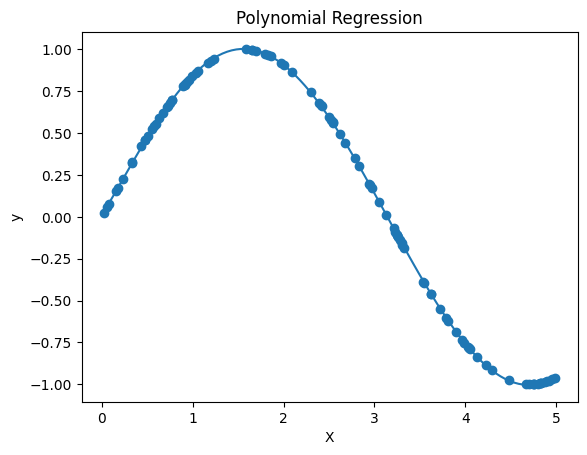

In [974]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate data
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel()

# Polynomial transform
poly = PolynomialFeatures(degree=5)
X_poly = poly.fit_transform(X)

# Train
model = LinearRegression()
model.fit(X_poly, y)

# Smooth curve
X_grid = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
X_grid_poly = poly.transform(X_grid)

# Plot
plt.scatter(X, y)
plt.plot(X_grid, model.predict(X_grid_poly))
plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

#### OBSERVATIONS:

1.  With the increase in the number of degrees, the best fit of line completely fits in the non linear data point.